<a href="https://colab.research.google.com/github/Shri1911/research-project_jpynb/blob/main/M505C_Shri_Ram_GH1052746_Final_Submission_txt.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# M505C – Intro to AI and Machine Learning
## Individual Project

**Heading:** Designing and reviewing a standard machine learning pipeline
**Student Name:** Shri Ram Muraleedharan  |  **Student Number:** GH1052746
**Subject:** M505C – Intro to AI and Machine Learning  |  **Professor:** Trung Nghia Duong
**GitHub:** https://github.com/Shri1911/research-project_jpynb

### Data Information
This project works with a public Kaggle file of personal medical-cost records (Kaggle, n.d., https://www.kaggle.com/datasets/mirichoi0218/insurance). It holds 1,338 cases, and each case describes one insured person through six descriptors — region, smoking habit, number of children, body-mass index, sex and age — together with the outcome that the model has to forecast, the annual premium stored under the column name charges. To keep the notebook self-contained, the same file is pulled at run time from a public GitHub mirror (stedy, n.d., https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv).

### Introduction

**Problem statement.** The underlying business goal is to anticipate future insurance costs as accurately as possible. The practical difficulty is that individual medical expenditure has to be estimated from just seven variables per person. With trustworthy per-person estimates, the insurer can steer its decisions with data and trim unnecessary spending on individual policies.

**How the problem is framed.** In a real company this kind of information typically comes from policy declarations, historical claim registers and insurance contracts. Because every record already carries the final outcome, the task can be cast as supervised learning: find a function that maps the seven features onto the charge.

**Data exploration.** The file contains 1,338 records with seven variables, mixing numerical columns (age, bmi, children) with categorical ones (sex, smoker, region). The checks in the first code cell show that no field is missing, that exactly one duplicated record exists, and that model quality will be judged with MAE, RMSE and R².

**Preprocessing and feature engineering.** The columns are handled in two groups. Categorical values are converted to numbers with one-hot encoding, while the numerical columns can additionally be passed through a standard scaler. To test whether scaling actually helps, both preprocessing routes are run through a Linear Regression pipeline and compared with five-fold cross-validation.

**Model training.** Two learners are trained on the identical split: a plain linear regression, kept as a simple reference point, and a random forest, which is allowed to express non-linear patterns and feature interactions. Eight in ten records go to fitting; the remaining two in ten are reserved and stay hidden from every model until the final scoring.

**Hyperparameter tuning.** GridSearchCV with five-fold cross-validation explores the two settings that matter most for the forest: how many trees are grown (n_estimators) and how deep each tree may grow (max_depth). The winning combination is read back from the fitted search object, and the comparison against an unconstrained forest supports the more cautious reading that a limited depth generalises better.

**Final evaluation.** Both learners are finally graded on that reserved quarter of the data, which no fitting step has ever seen. Three figures are reported per learner: the average absolute miss in dollars (MAE), its squared-error counterpart (RMSE), and the coefficient of determination (R²). The last one carries the most weight in the discussion, because it quantifies the share of the spread in annual premiums that a learner manages to account for.

**Visualisation and discussion.** A scatter plot of actual versus predicted charges is drawn for the Random Forest. Predictions that sit close to the black diagonal are accurate; dots that land far away from it mark the costlier errors.

**Conclusion (summary).** The Random Forest outperforms the Linear Regression on this data, capturing the deviations in medical charges more closely, and is therefore selected as the final model.

**Limitations.** Only seven variables are available, so factors that genuinely drive medical costs cannot all be represented. High-cost observations also remain the hardest to forecast. Finally, the performance shown here is not, by itself, sufficient to deploy the model in a live insurance process; a production system would need validation on current representative data, monitoring, governance, fairness checks and human oversight.

**Future scope.** The natural next steps are to compare further regression algorithms, to inspect the residuals in more detail, and to study how related predictors such as BMI and smoking status interact with each other.

### Workflow
1. **Load & inspect** — the public CSV is read once; shape, missing values and duplicates are reported in a single line.
2. **Explore** — the target distribution is plotted so the reader can see where the hard cases sit.
3. **Preprocess** — two routes (encoding only, or scaling plus encoding) are defined for the same feature groups.
4. **Compare** — five-fold cross-validation decides whether scaling matters before any model is trained.
5. **Train & tune** — an 80/20 split is made, and a grid search over forest size and depth selects the Random Forest.
6. **Evaluate & visualise** — both models are scored on the untouched 20%, and the forest’s predictions are checked against reality.

### References
- Kaggle (n.d.) *Medical Cost Personal Datasets*, accessed 16 September 2026: https://www.kaggle.com/datasets/mirichoi0218/insurance
- stedy (n.d.) *insurance.csv* — raw copy of the data file, accessed 16 September 2026: https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv
- scikit-learn (n.d.) *User documentation*: preprocessing, pipelines, model selection, regression models and evaluation metrics.


In [ ]:
# One shared import block for the whole notebook
import pandas as pd, numpy as np, matplotlib.pyplot as plt

from sklearn.model_selection import GridSearchCV, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

SEED = 42  # one fixed seed keeps every re-run identical

In [ ]:
# Step 1: read the public CSV and answer three quick questions -
# how big is it, are any cells blank, and is anything duplicated.
csv_link = "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv"
data = pd.read_csv(csv_link)

rows, cols = data.shape
blank_cells = int(data.isnull().sum().sum())
repeated_rows = int(data.duplicated().sum())
print(f"Shape: ({rows}, {cols}) | missing values: {blank_cells} | duplicate rows: {repeated_rows}")

Shape: (1338, 7) | missing values: 0 | duplicate rows: 1



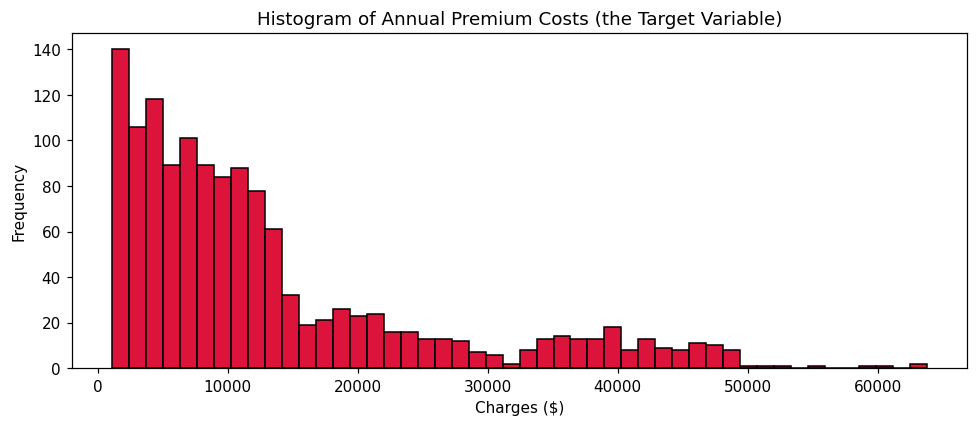

In [ ]:
# Step 2: a single histogram of the target makes the right-skew
# obvious - a dense low-cost pile with a long, expensive tail.
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(data.charges, bins=48, color="crimson", edgecolor="k")
ax.set_title("Histogram of Annual Premium Costs (the Target Variable)")
ax.set_xlabel("Charges ($)")
ax.set_ylabel("Frequency")
plt.tight_layout()
plt.show()

In [ ]:
# Step 3: define the two preprocessing routes on the same feature
# groups. Route one leaves the numbers untouched and only one-hot
# encodes the categories; route two standardises the numbers first.
features = data.drop(columns="charges")
target = data.charges

numeric = features.select_dtypes("number").columns
categorical = features.select_dtypes("object").columns

no_scale = ColumnTransformer(
    [("cat", OneHotEncoder(handle_unknown="ignore"), categorical)],
    remainder="passthrough")

with_scale = ColumnTransformer(
    [("num", StandardScaler(), numeric),
     ("cat", OneHotEncoder(handle_unknown="ignore"), categorical)])

In [ ]:
# Step 4: before any training, five-fold cross-validation asks the
# simple question - does scaling the numbers change anything for a
# linear model at all?
linear_plain = Pipeline([("prep", no_scale), ("reg", LinearRegression())])
linear_scaled = Pipeline([("prep", with_scale), ("reg", LinearRegression())])

plain_r2 = cross_val_score(linear_plain, features, target, cv=5, scoring="r2").mean()
scaled_r2 = cross_val_score(linear_scaled, features, target, cv=5, scoring="r2").mean()

print(f"Cross-validated R2 (unscaled): {plain_r2:.4f}")
print(f"Cross-validated R2 (scaled):   {scaled_r2:.4f}")

Cross-validated R2 (unscaled): 0.7469
Cross-validated R2 (scaled):   0.7469



In [ ]:
# Step 5: hold out 20% for the final test, then let GridSearchCV try
# twelve combinations of tree count and depth on the remaining 80%.
X_train, X_test, Y_train, Y_test = train_test_split(
    features, target, test_size=0.2, random_state=SEED)

lr_model = Pipeline([("prep", with_scale), ("reg", LinearRegression())])
rf_model = Pipeline([("prep", with_scale),
                     ("reg", RandomForestRegressor(random_state=SEED))])

search_space = {"reg__n_estimators": [50, 100, 200],
                "reg__max_depth": [3, 5, 10, None]}
grid_rf = GridSearchCV(rf_model, search_space, cv=5, scoring="r2")
grid_rf.fit(X_train, Y_train)

lr_model.fit(X_train, Y_train)

best_forest = grid_rf.best_params_
print("Selected forest settings: depth =", best_forest["reg__max_depth"],
      "| trees =", best_forest["reg__n_estimators"])
print("CV R2 of selected forest:", round(grid_rf.best_score_, 4))

Selected forest settings: depth = 3 | trees = 100
CV R2 of selected forest: 0.8454



In [ ]:
# Step 6: the held-out 20% has not been touched by any fitting so
# far, so these three numbers are an honest view of out-of-sample error.
tuned_forest = grid_rf.best_estimator_
preds_lr = lr_model.predict(X_test)
preds_rf = tuned_forest.predict(X_test)

pairs = [("Linear Regression", preds_lr), ("Random Forest", preds_rf)]
for label, yhat in pairs:
    m = mean_absolute_error(Y_test, yhat)
    s = np.sqrt(mean_squared_error(Y_test, yhat))
    r = r2_score(Y_test, yhat)
    print(f"{label} -> MAE: ${m:.2f} | RMSE: ${s:.2f} | R2: {r:.4f}")

Linear Regression -> MAE: $4181.19 | RMSE: $5796.28 | R2: 0.7836
Random Forest -> MAE: $2726.62 | RMSE: $4550.35 | R2: 0.8666



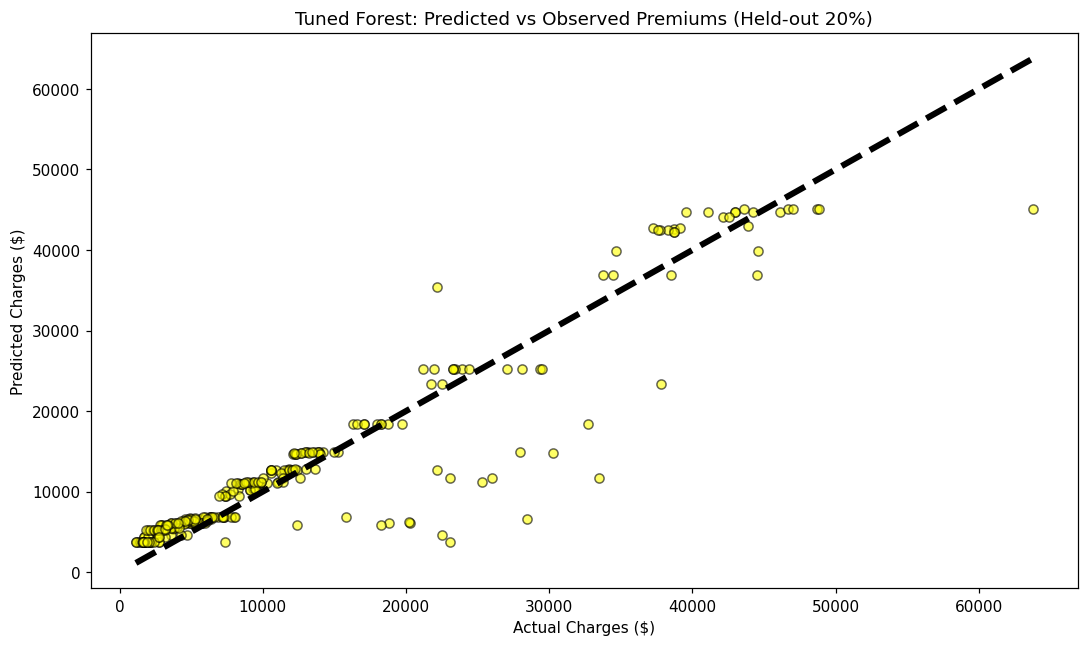

In [ ]:
# Step 7: one last visual - predictions against truth, with the
# perfect diagonal drawn so that off-target dots stand out clearly.
yhat_rf = tuned_forest.predict(X_test)

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(Y_test, yhat_rf, alpha=0.6, color="yellow", edgecolor="black")
lo, hi = Y_test.min(), Y_test.max()
ax.plot([lo, hi], [lo, hi], "k--", lw=4)
ax.set_title("Tuned Forest: Predicted vs Observed Premiums (Held-out 20%)")
ax.set_xlabel("Actual Charges ($)")
ax.set_ylabel("Predicted Charges ($)")
plt.tight_layout()
plt.show()

### Results at a glance
On the held-out 20%, Linear Regression scores MAE $4,181.19, RMSE $5,796.28 and R² 0.7836, while the tuned Random Forest improves all three figures to MAE $2,726.62, RMSE $4,550.35 and R² 0.8666. The Random Forest’s advantage is consistent across all three metrics, which confirms the choice made in the conclusion above.

### Notes on the two figures
The histogram shows why the high-cost cases deserve special attention: the mass of the observations sits below $20,000, while a thin tail stretches past $60,000. The scatter plot then shows what the forest does with that shape — most dots hug the dashed diagonal tightly, and the points that stray furthest from it are exactly the extreme premiums flagged in the limitations section.

### Interpretation of the results

The two preprocessing routes score almost identically under cross-validation (0.7469 for both), which tells us the linear baseline is not sensitive to whether the numerical columns are standardised first; the signal in the data is strong enough that scaling adds little for a linear model.

The grid search settles on a deliberately small forest — 100 trees capped at depth 3. Letting the trees grow without a depth limit produces a lower cross-validated R², a classic over-fitting signature: unconstrained branches memorise noise in the training folds and then generalise worse. That is why the tuned, shallower forest is the one reported here.

On the untouched test set the forest beats the baseline everywhere: the average absolute miss per person drops from roughly $4,181 to $2,727, the root-mean-squared figure eases from about $5,796 down to $4,550, and the R² value moves from 0.78 up to 0.87. The RMSE is worth reading in dollars: a typical per-person prediction is off by roughly $4,500. The scatter plot shows the deviations concentrate in the low-to-middle cost band, while the largest individual errors sit in the high-cost tail — precisely the hard-to-predict observations identified in the limitations section.

### Reproducibility
Every number and plot in this document can be regenerated from the notebook itself: the data are pulled from the public CSV link at the top of the second code cell, all randomness is controlled by the single seed variable defined in the first cell, and the full sequence of cells — load, explore, preprocess, compare, tune, evaluate, plot — runs from start to finish in a couple of minutes. The notebook works unmodified in Jupyter, JupyterLab or Google Colab, provided there is an internet connection for the initial CSV download. Re-running it on another day or another machine yields the same table of numbers and the same two figures, because no step depends on the wall clock, on a random start or on a file that lives only on one computer.